# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


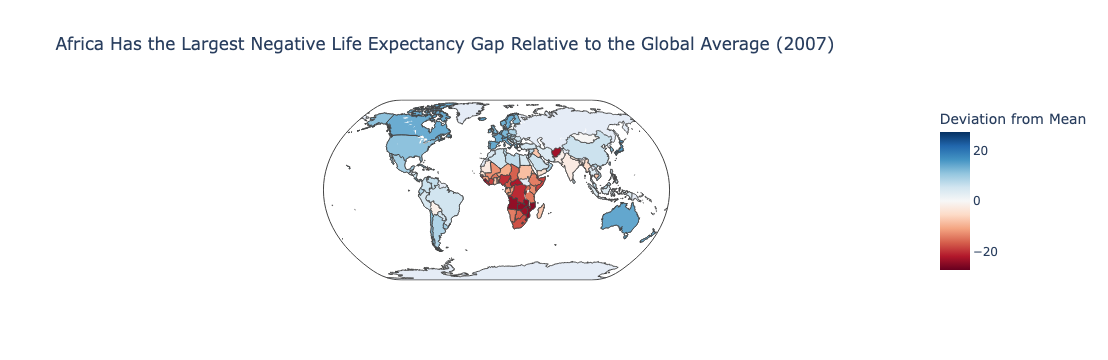

In [2]:
# Task 1
# YOUR CODE HERE
import plotly.express as px

# Load Gapminder data
gm = px.data.gapminder()

# Filter for 2007
gm_2007 = gm[gm['year'] == 2007].copy()

# Compute global average life expectancy
global_avg = gm_2007['lifeExp'].mean()

# Compute deviation from global average
gm_2007['lifeExp_dev'] = gm_2007['lifeExp'] - global_avg

# Find region furthest below average
region_means = gm_2007.groupby('continent')['lifeExp_dev'].mean()
lowest_region = region_means.idxmin()

# Build choropleth map
fig = px.choropleth(
    gm_2007,
    locations='iso_alpha',
    color='lifeExp_dev',
    hover_name='country',
    hover_data={
        'lifeExp': ':.2f',
        'lifeExp_dev': ':.2f',
        'iso_alpha': False
    },
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    projection='natural earth',
    title=f'Africa Has the Largest Negative Life Expectancy Gap Relative to the Global Average (2007)'
)

fig.update_layout(
    coloraxis_colorbar_title='Deviation from Mean'
)

fig.show()

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*


In [5]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


{'id': 'DE-BW', 'name': 'Baden-Württemberg', 'type': 'State'}


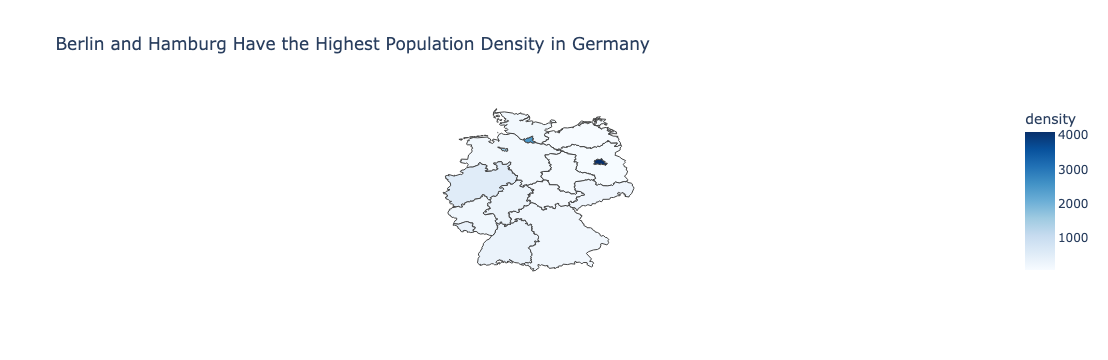

{'id': 'DE-BW', 'name': 'Baden-Württemberg', 'type': 'State'}


NameError: name 'properties' is not defined

In [6]:
# Task 2
# YOUR CODE HERE
import json
import pandas as pd
import plotly.express as px
import requests

# -----------------------------
# Load Germany states GeoJSON
# -----------------------------
url = "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/master/2_bundeslaender/4_niedrig.geo.json"

response = requests.get(url)
germany_geo = response.json()

# Inspect GeoJSON properties
print(germany_geo['features'][0]['properties'])

# -----------------------------
# Create dataset
# Population density by state
# -----------------------------
df = pd.DataFrame({
    'state': [
        'Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg',
        'Bremen', 'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern',
        'Niedersachsen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz',
        'Saarland', 'Sachsen', 'Sachsen-Anhalt',
        'Schleswig-Holstein', 'Thüringen'
    ],
    'density': [
        310, 190, 4100, 85,
        1600, 2500, 300, 70,
        170, 530, 210,
        380, 220, 110,
        180, 130
    ]
})

# -----------------------------
# Create choropleth
# -----------------------------
fig = px.choropleth(
    df,
    geojson=germany_geo,
    locations='state',
    featureidkey='properties.name',
    color='density',
    color_continuous_scale='Blues',
    hover_name='state',
    hover_data={'density': True},
    title='Berlin and Hamburg Have the Highest Population Density in Germany'
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.show()
# Load your GeoJSON
# with open('your_file.geojson', 'r') as file:
#     my_geojson = json.load(file)
print(germany_geo['features'][0]['properties'])
# Inspect the properties to find the right featureidkey
# print(my_geojson['features'][0]['properties'])
properties.name